# Supervised Learning - Stage 2

Stage 2 covers:
- Address the severe class imbalance before training any models (we do this using SMOTE which generates synthetic samples for the minority classes by interpolating between existing examples in feature space -- unlike random sampling which simply duplicates records).

Note:
- SMOTE is only applied to the training set. The test set is untouched to ensure it represents a real world class distribution to give honest evaluation metrics.

In [ ]:
# Install the relevant packages in the environment this notebook runs in
import sys  # noqa: F401

!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy pyyaml pypickle imbalanced-learn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pickle
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')

ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'

with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide':    nb_cfg['plotting']['figsize_wide'],
    'palette':         nb_cfg['plotting']['palette'],
    'severity_labels': {int(k): v for k, v in nb_cfg['labels']['severity'].items()},
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Configs loaded.')

Project root: C:\Users\abdul\Documents\SHU\AI 1\Sheffield-Road-Collision-Detection-Coursework
Configs loaded.


---
# 2. Load Stage 1 Outputs

In [8]:
with open(ROOT_DIR / 'notebooks' / 'stage_outputs' / 'stage1.pkl', 'rb') as f:
    stage1 = pickle.load(f)

X_train = stage1['X_train']
X_test  = stage1['X_test']
y_train = stage1['y_train']
y_test  = stage1['y_test']

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'Training class distribution: {Counter(y_train)}')

X_train: (5859, 28)
X_test: (1465, 28)
Training class distribution: Counter({3: 4882, 2: 903, 1: 74})


---
# 3. Why SMOTE Over Alternatives

| Strategy | Approach | Drawback |
|----------|----------|----------|
| `class_weight='balanced'` | Penalises misclassification of minority classes during training | Doesn't change the data distribution - limited effect with 66:1 ratio |
| Random oversampling | Duplicates existing minority records | Promotes overfitting - model memorises duplicates |
| Random undersampling | Removes majority records | Discards 83% of training data - significant information loss |
| **SMOTE** | Synthesises new minority samples by interpolating between neighbours | Increases minority class diversity without exact duplication |

Given the extreme imbalance ratio (~66:1 Slight vs Fatal), SMOTE is the most principled
choice. We still combine it with `class_weight` in models where applicable.

---
# 4. Apply SMOTE

In [9]:
smote = SMOTE(
    random_state=cfg['supervised']['smote_random_state'],
    k_neighbors=5
)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Class distribution before SMOTE:')
before = Counter(y_train)
for cls, count in sorted(before.items()):
    print(f'\t{NB_CONFIG["severity_labels"][cls]:8s} (class {cls}): {count:5,}')
    
print('\nClass distribution after SMOTE:')
after = Counter(y_train_resampled)
for cls, count in sorted(after.items()):
    print(f'\t{NB_CONFIG["severity_labels"][cls]:8s} (class {cls}): {count:5,}')
    
print(f'\nTraining samples before: {len(X_train):,}')
print(f'Training samples after:  {len(X_train_resampled):,}')
print(f'Synthetic samples added: {len(X_train_resampled) - len(X_train):,}')

Class distribution before SMOTE:
	Fatal    (class 1):    74
	Serious  (class 2):   903
	Slight   (class 3): 4,882

Class distribution after SMOTE:
	Fatal    (class 1): 4,882
	Serious  (class 2): 4,882
	Slight   (class 3): 4,882

Training samples before: 5,859
Training samples after:  14,646
Synthetic samples added: 8,787


---
# 5. Visualize Before and After

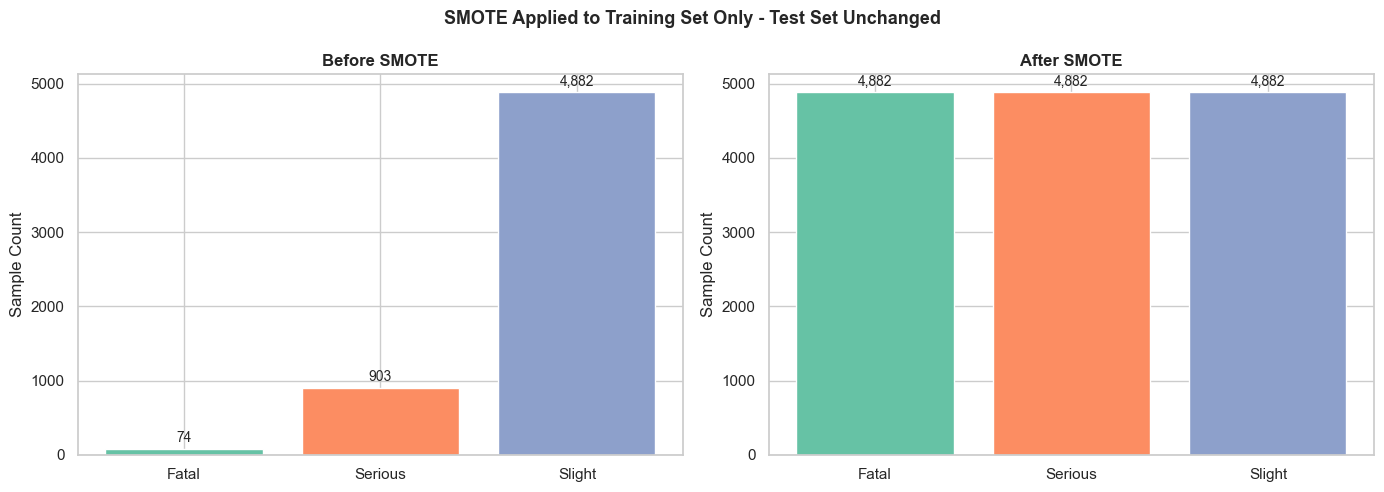

In [10]:
fig, axes = plt.subplots(1, 2, figsize=tuple(NB_CONFIG['figsize_wide']))
colors = sns.color_palette(NB_CONFIG['palette'], 3)
labels = [NB_CONFIG['severity_labels'][k] for k in sorted(before.keys())]

before_counts = [before[k] for k in sorted(before.keys())]
bars = axes[0].bar(labels, before_counts, color=colors, edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sample Count')
for bar, count in zip(bars, before_counts, strict=False):
    axes[0].annotate(
        f'{count:,}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5), textcoords='offset points',
        ha='center', fontsize=10
    )

after_counts = [after[k] for k in sorted(after.keys())]
bars = axes[1].bar(labels, after_counts, color=colors, edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sample Count')
for bar, count in zip(bars, after_counts, strict=False):
    axes[1].annotate(
        f'{count:,}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5), textcoords='offset points',
        ha='center', fontsize=10
    )

fig.suptitle(
    'SMOTE Applied to Training Set Only - Test Set Unchanged',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [11]:
# Confirm test set is untouched
test_dist = Counter(y_test)
print('Test set class distribution (must reflect real-world proportions):')
for cls, count in sorted(test_dist.items()):
    pct = count / len(y_test) * 100
    print(f'\t{NB_CONFIG["severity_labels"][cls]:8s} (class {cls}): {count:4,}  ({pct:.1f}%)')

Test set class distribution (must reflect real-world proportions):
	Fatal    (class 1):   19  (1.3%)
	Serious  (class 2):  226  (15.4%)
	Slight   (class 3): 1,220  (83.3%)


---
## 6. Stage 2 Summary

| Item | Before SMOTE | After SMOTE |
|------|-------------|-------------|
| Fatal samples | 74 | equalised |
| Serious samples | 903 | equalised |
| Slight samples | 4,882 | equalised |
| Total training samples | 5,859 | 14,646 |

The resampled training set is balanced across all three classes. All downstream model
training in Stages 3–7 uses `X_train_resampled` and `y_train_resampled`.  
Evaluation in Stage 8 uses the **original, untouched** `X_test` and `y_test`.

In [12]:
# Persist for next stage
output_path = ROOT_DIR / 'notebooks' / 'stage_outputs' / 'stage2.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'X_train_resampled': X_train_resampled,
        'y_train_resampled': y_train_resampled,
        'X_test':            X_test,
        'y_test':            y_test,
    }, f)

print(f'Stage 2 outputs saved to: {output_path}')

Stage 2 outputs saved to: C:\Users\abdul\Documents\SHU\AI 1\Sheffield-Road-Collision-Detection-Coursework\notebooks\stage_outputs\stage2.pkl
